# Exploração inicial das bases

Mastercard Challenge 2026 — Inteli

O Priceless Bank perdeu share: 33% no 1T25 para 19% no 4T25, segundo o benchmarking da Mastercard.
Recebemos cinco bases de dados. Este notebook é o primeiro contato com elas.

Perguntas que queremos responder aqui:

- o que tem em cada base
- quem é o cliente
- onde a queda aparece nos dados
- os dados são confiáveis

Depois disso vêm a limpeza (notebook 2), o teste das hipóteses (notebook 3) e as recomendações.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

# cores e estilo dos gráficos
AZUL, LARANJA, VERDE, ROXO, ROSA, VERMELHO = '#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7', '#e87ba4', '#e34948'
TINTA, TINTA2, CINZA, GRADE, FUNDO = '#0b0b0b', '#52514e', '#8a8880', '#e6e5e1', '#fcfcfb'

mpl.rcParams.update({
    'figure.facecolor': FUNDO, 'axes.facecolor': FUNDO, 'savefig.facecolor': FUNDO,
    'axes.edgecolor': GRADE, 'axes.grid': True, 'axes.grid.axis': 'y', 'axes.axisbelow': True,
    'grid.color': GRADE, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': TINTA,
    'axes.titlelocation': 'left', 'axes.titlepad': 12,
    'axes.labelsize': 9.5, 'axes.labelcolor': TINTA2,
    'xtick.color': TINTA2, 'ytick.color': TINTA2, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.major.size': 0, 'ytick.major.size': 0, 'legend.frameon': False,
    'lines.linewidth': 2.0, 'font.size': 10, 'figure.dpi': 110,
})

mil = FuncFormatter(lambda v, p: f'{v:,.0f}'.replace(',', '.'))
pc  = FuncFormatter(lambda v, p: f'{v:.0f}%')
rs  = FuncFormatter(lambda v, p: f'R$ {v:,.0f}'.replace(',', '.'))

## Carregando as bases

Cada arquivo usa um formato de data diferente, então converto todos na carga.

In [2]:
clientes = pd.read_csv('Base_clientes_v4.csv')
cartoes  = pd.read_csv('Base_cartoes_v4.csv')
transac  = pd.read_csv('Base_transacoes_v4.csv')
pix      = pd.read_csv('Base_pix_v4.csv')
invest   = pd.read_csv('Base_investimentos_v4.csv')

clientes['Data_Criacao_Conta'] = pd.to_datetime(clientes.Data_Criacao_Conta)      # 2023-01-05
clientes['Data_Nascimento']    = pd.to_datetime(clientes.Data_Nascimento, format='%d/%m/%Y')
cartoes['Data_Emissao']        = pd.to_datetime(cartoes.Data_Emissao)
cartoes['Data_Ativacao']       = pd.to_datetime(cartoes.Data_Ativacao)
transac['Data']                = pd.to_datetime(transac.Data)
pix['Data']                    = pd.to_datetime(pix.Data, errors='coerce')
invest['Data']                 = pd.to_datetime(invest.Data.astype(str), format='%Y%m')   # 202407

for nome, df in [('clientes', clientes), ('cartoes', cartoes), ('transacoes', transac),
                 ('pix', pix), ('investimentos', invest)]:
    print(f'{nome:<15} {df.shape[0]:>7,} linhas   {df.shape[1]:>2} colunas'.replace(',', '.'))

clientes          1.960 linhas    8 colunas
cartoes           4.006 linhas    7 colunas
transacoes      156.826 linhas   14 colunas
pix             278.940 linhas    8 colunas
investimentos    21.200 linhas    7 colunas


In [3]:
# o que é uma linha em cada base
for nome, df in [('clientes', clientes), ('cartoes', cartoes), ('transacoes', transac),
                 ('pix', pix), ('investimentos', invest)]:
    print(nome, '->', list(df.columns))
    print()

clientes -> ['Cliente_ID', 'Data_Nascimento', 'Renda_Anual', 'Data_Criacao_Conta', 'Numero_Cartoes', 'Cidade', 'Estado', 'Possui_Conta_Adicional']

cartoes -> ['ID_Cartao', 'Produto_Mastercard', 'Tipo_Cartao', 'Data_Emissao', 'Data_Ativacao', 'Data_Validade', 'Limite_Cartao']

transacoes -> ['ID_Transacao', 'Data', 'Valor_Compra', 'Industria', 'Tipo_Compra', 'Qtd_Parcelas', 'Wallet', 'Cliente_ID', 'ID_Cartao', 'Input_Mode', 'Input_Mode_Code', 'Crossborder', 'Contactless', 'Autorizado']

pix -> ['Cliente_ID', 'Valor', 'Data', 'Pix_para_si_mesmo', 'Tipo_transacao', 'Aprovado', 'PF_PJ', 'Agendado']

investimentos -> ['Cliente_ID', 'Data_Abertura_Conta_Inv', 'Data', 'Valor_Aplicado', 'Saldo_Atual', 'Produto_Investimento', 'Data_de_vencimento']



Granularidades:

| base | uma linha é | chave |
|---|---|---|
| clientes | um cliente | `Cliente_ID` |
| cartoes | um cartão | `ID_Cartao` |
| transacoes | uma compra no cartão | `ID_Transacao` |
| pix | um PIX | não tem |
| investimentos | cliente × produto × mês | `Cliente_ID` + produto + data |

Duas coisas chamam atenção já aqui: a base de cartões não tem `Cliente_ID`, então não dá para saber
de quem é o cartão sem passar pela base de transações; e a base de PIX não tem chave primária nenhuma.

In [4]:
# quantos dos 1.960 clientes usam cada produto
usa_cartao = clientes.Cliente_ID.isin(transac.Cliente_ID)
usa_pix    = clientes.Cliente_ID.isin(pix.Cliente_ID)
investe    = clientes.Cliente_ID.isin(invest.Cliente_ID)
sem_nada   = ~(usa_cartao | usa_pix | investe)

print(f'usam cartão : {usa_cartao.sum():>5}  ({usa_cartao.mean():.1%})')
print(f'usam pix    : {usa_pix.sum():>5}  ({usa_pix.mean():.1%})')
print(f'investem    : {investe.sum():>5}  ({investe.mean():.1%})')
print(f'nada        : {sem_nada.sum():>5}  ({sem_nada.mean():.1%})')

print(f'\nperíodo dos dados:')
print(f'  transacoes    {transac.Data.min():%Y-%m} a {transac.Data.max():%Y-%m}')
print(f'  pix           {pix.Data.min():%Y-%m} a {pix.Data.max():%Y-%m}')
print(f'  investimentos {invest.Data.min():%Y-%m} a {invest.Data.max():%Y-%m}')

usam cartão :  1431  (73.0%)
usam pix    :  1430  (73.0%)
investem    :  1003  (51.2%)
nada        :    85  (4.3%)

período dos dados:
  transacoes    2023-01 a 2025-12
  pix           2023-01 a 2025-12
  investimentos 2023-01 a 2025-12


Metade da base investe. Guardo esse número, ele volta no notebook 3.

## Perfil do cliente

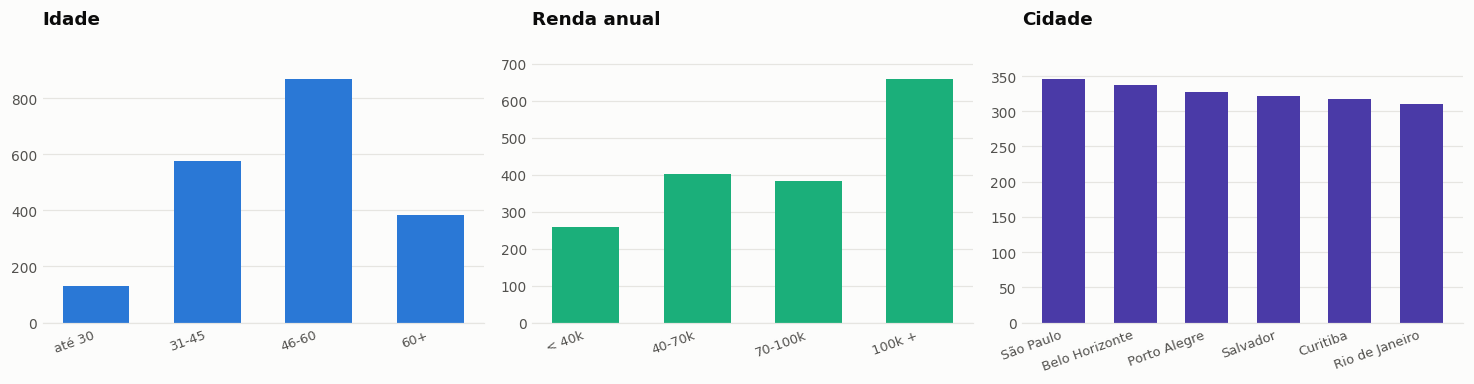

idade mediana      50 anos
renda mediana      R$ 85.000
renda não informada 255 clientes (13.0%)
cartões por cliente 2.5 em média


In [5]:
REF = pd.Timestamp('2025-12-31')
clientes['idade'] = ((REF - clientes.Data_Nascimento).dt.days / 365.25).round(0)
clientes['faixa_etaria'] = pd.cut(clientes.idade, [0, 30, 45, 60, 200], labels=['até 30','31-45','46-60','60+'])
clientes['faixa_renda']  = pd.cut(clientes.Renda_Anual, [0, 40e3, 70e3, 100e3, np.inf],
                                  labels=['< 40k','40-70k','70-100k','100k +'])

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
for ax, s, cor, tit in [
        (axes[0], clientes.faixa_etaria.value_counts().reindex(['até 30','31-45','46-60','60+']), AZUL, 'Idade'),
        (axes[1], clientes.faixa_renda.value_counts().reindex(['< 40k','40-70k','70-100k','100k +']), VERDE, 'Renda anual'),
        (axes[2], clientes.Cidade.value_counts(), ROXO, 'Cidade')]:
    ax.bar(range(len(s)), s.values, width=0.6, color=cor)
    ax.set_xticks(range(len(s)), s.index, rotation=20, ha='right', fontsize=8.5)
    ax.set_ylim(0, s.max()*1.15)
    ax.set_title(tit)
plt.tight_layout(); plt.show()

print(f'idade mediana      {clientes.idade.median():.0f} anos')
print(f'renda mediana      R$ {clientes.Renda_Anual.median():,.0f}'.replace(',', '.'))
print(f'renda não informada {clientes.Renda_Anual.isna().sum()} clientes ({clientes.Renda_Anual.isna().mean():.1%})')
print(f'cartões por cliente {clientes.Numero_Cartoes.mean():.1f} em média')

Base bem distribuída: seis capitais com peso parecido, idade mediana de 50 anos, renda mediana de
R$ 85 mil. 255 clientes estão sem renda no cadastro.

## Onde está a queda

Uso contagem de transações, não valor em reais. O motivo aparece na última seção.

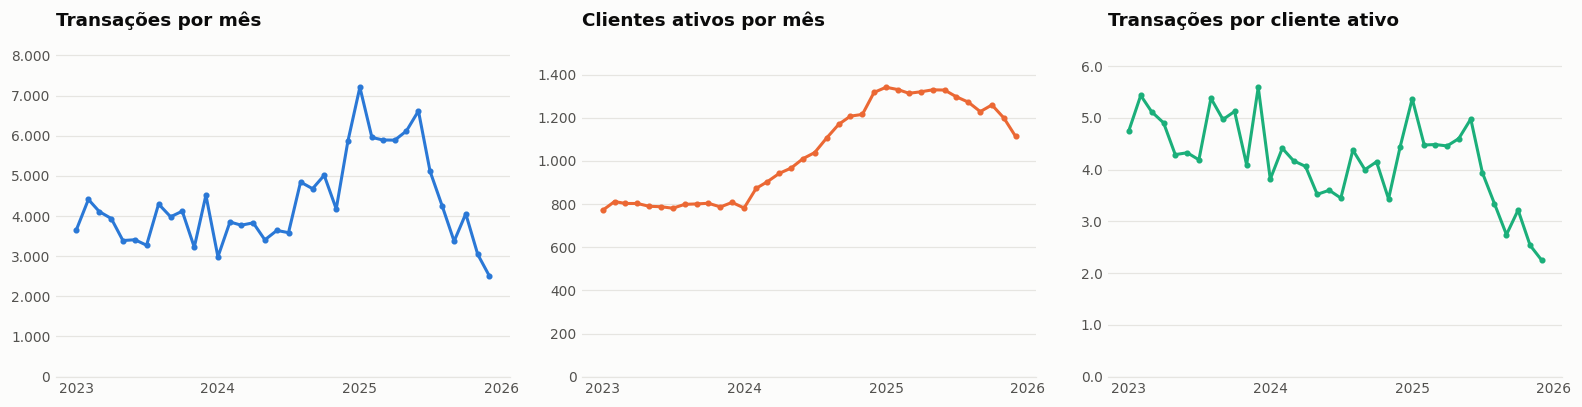

In [6]:
aut = transac[transac.Autorizado == 'Sim'].copy()
aut['mes']  = aut.Data.dt.to_period('M')
aut['trim'] = aut.Data.dt.to_period('Q')

mensal = aut.groupby('mes').agg(transacoes=('ID_Transacao','size'), clientes=('Cliente_ID','nunique'))
mensal['por_cliente'] = mensal.transacoes / mensal.clientes

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.8))
for ax, col, cor, tit, fmt in [
        (axes[0], 'transacoes',  AZUL,    'Transações por mês', mil),
        (axes[1], 'clientes',    LARANJA, 'Clientes ativos por mês', mil),
        (axes[2], 'por_cliente', VERDE,   'Transações por cliente ativo', FuncFormatter(lambda v,p: f'{v:.1f}'))]:
    x, y = mensal.index.to_timestamp(), mensal[col].values
    ax.plot(x, y, color=cor, marker='o', markersize=3)
    ax.set_ylim(0, max(y)*1.15)
    ax.yaxis.set_major_formatter(fmt)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_title(tit)
plt.tight_layout(); plt.show()

In [7]:
# separando o efeito: menos clientes ou menos uso por cliente?
q = aut.groupby('trim').agg(transacoes=('ID_Transacao','size'), clientes=('Cliente_ID','nunique'))
q['por_cliente'] = (q.transacoes / q.clientes).round(1)
print(q.to_string())

a, b = q.loc['2025Q1'], q.loc['2025Q4']
print(f'\n1T25 -> 4T25')
print(f'  transacoes  {a.transacoes:>6,.0f} -> {b.transacoes:>6,.0f}   {100*(b.transacoes/a.transacoes-1):+.1f}%'.replace(',', '.'))
print(f'  clientes    {a.clientes:>6,.0f} -> {b.clientes:>6,.0f}   {100*(b.clientes/a.clientes-1):+.1f}%'.replace(',', '.'))
print(f'  por cliente {a.por_cliente:>6.1f} -> {b.por_cliente:>6.1f}   {100*(b.por_cliente/a.por_cliente-1):+.1f}%')

        transacoes  clientes  por_cliente
trim                                     
2023Q1       12180       843         14.4
2023Q2       10735       843         12.7
2023Q3       11550       849         13.6
2023Q4       11860       849         14.0
2024Q1       10607       955         11.1
2024Q2       10877      1089         10.0
2024Q3       13111      1235         10.6
2024Q4       15048      1381         10.9
2025Q1       19056      1403         13.6
2025Q2       18622      1402         13.3
2025Q3       12740      1377          9.3
2025Q4        9601      1361          7.1

1T25 -> 4T25
  transacoes  19.056 ->  9.601   -49.6%
  clientes     1.403 ->  1.361   -3.0%
  por cliente   13.6 ->    7.1   -47.8%


A carteira de clientes quase não mudou (-3%), mas o uso por cliente caiu quase pela metade (-48%).
Ou seja, os clientes continuam no banco e usam menos. Isso não parece churn.

Se a base atual usa menos, a próxima pergunta é se pelo menos entram clientes novos.

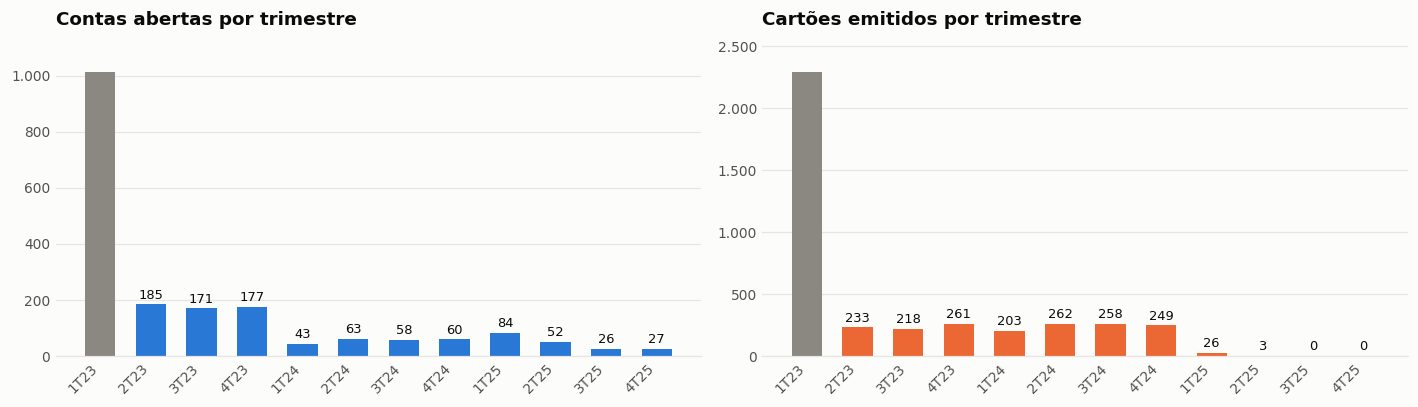

contas novas por trimestre em 2023: 178
contas novas por trimestre em 2024: 56
contas novas por trimestre em 2025: 47

cartões emitidos depois de mai/2025: 0


In [8]:
novas   = clientes.groupby(clientes.Data_Criacao_Conta.dt.to_period('Q')).size()
emissao = cartoes.groupby(cartoes.Data_Emissao.dt.to_period('Q')).size()
idx = pd.period_range('2023Q1', '2025Q4', freq='Q')
novas, emissao = novas.reindex(idx, fill_value=0), emissao.reindex(idx, fill_value=0)
rotulo = [f'{p.quarter}T{str(p.year)[2:]}' for p in idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, s, cor, tit in [(axes[0], novas, AZUL, 'Contas abertas por trimestre'),
                        (axes[1], emissao, LARANJA, 'Cartões emitidos por trimestre')]:
    # o 1T23 é a carga inicial da base, não é aquisição
    ax.bar(range(len(s)), s.values, width=0.6, color=[CINZA if i == 0 else cor for i in range(len(s))])
    ax.set_xticks(range(len(s)), rotulo, rotation=45, ha='right')
    for i, v in enumerate(s.values):
        if i > 0:
            ax.text(i, v + s.max()*0.02, str(v), ha='center', fontsize=8.5, color=TINTA)
    ax.set_ylim(0, s.max()*1.1); ax.yaxis.set_major_formatter(mil)
    ax.set_title(tit)
plt.tight_layout(); plt.show()

pos = novas[novas.index > pd.Period('2023Q1')]   # tira a carga inicial
for ano in (2023, 2024, 2025):
    print(f'contas novas por trimestre em {ano}: {pos[pos.index.year == ano].mean():.0f}')
print(f'\ncartões emitidos depois de mai/2025: {int((cartoes.Data_Emissao >= "2025-06-01").sum())}')

A aquisição caiu de ~178 contas por trimestre em 2023 para 26 e 27 nos dois últimos. E a emissão de
cartão parou completamente em maio de 2025. Não sabemos ainda se isso foi decisão do banco ou falta
de demanda — fica como pergunta para o notebook 3.

## Qualidade dos dados

Três problemas que limitam o que dá para afirmar no resto do trabalho.

### 1. Colunas vazias

In [9]:
linhas = []
for nome, df in [('clientes', clientes), ('cartoes', cartoes), ('transacoes', transac),
                 ('pix', pix), ('investimentos', invest)]:
    s = df.isna().sum()
    for col, q_ in s[s > 0].items():
        if col in ('idade', 'faixa_etaria', 'faixa_renda'):
            continue
        linhas.append((nome, col, int(q_), 100*q_/len(df)))

nulos = pd.DataFrame(linhas, columns=['base','coluna','vazios','pct']).sort_values('pct', ascending=False)
print(nulos.to_string(index=False, float_format=lambda v: f'{v:.1f}'))

print('\nCrossborder e Contactless: como ficam os poucos valores preenchidos?')
for col in ['Crossborder', 'Contactless']:
    vc = transac[col].value_counts()
    print(f'  {col}: preenchidos {vc.sum():,}'.replace(',', '.'),
          '| ' + '  '.join(f'{int(k)} = {100*v/vc.sum():.1f}%' for k, v in vc.sort_index().items()))

         base         coluna  vazios  pct
   transacoes    Crossborder  149912 95.6
   transacoes         Wallet  134716 85.9
   transacoes    Contactless  129332 82.5
   transacoes   Qtd_Parcelas  113252 72.2
     clientes    Renda_Anual     255 13.0
      cartoes  Data_Validade     450 11.2
          pix           Data     418  0.1
          pix Tipo_transacao     418  0.1
investimentos Valor_Aplicado      14  0.1
investimentos    Saldo_Atual      14  0.1

Crossborder e Contactless: como ficam os poucos valores preenchidos?
  Crossborder: preenchidos 6.914 | 0 = 50.1%  1 = 49.9%
  Contactless: preenchidos 27.494 | 0 = 49.7%  1 = 50.3%


`Qtd_Parcelas` e `Wallet` vazios provavelmente significam alguma coisa, e o notebook 2 investiga cada
um. Já `Crossborder` (95,6% vazio) e `Contactless` (82,5%) são perda mesmo: nos poucos preenchidos a
divisão é 50/50, então não tem sinal ali. Azar, porque são justamente as colunas que mediriam
maturidade digital, que é um dos eixos do benchmarking.

### 2. O valor em reais muda de escala no meio da série

Comparei a mediana mensal do valor. A mediana é insensível a outlier, então um salto nela indica
mudança no processo que gerou o dado, não mudança de comportamento.

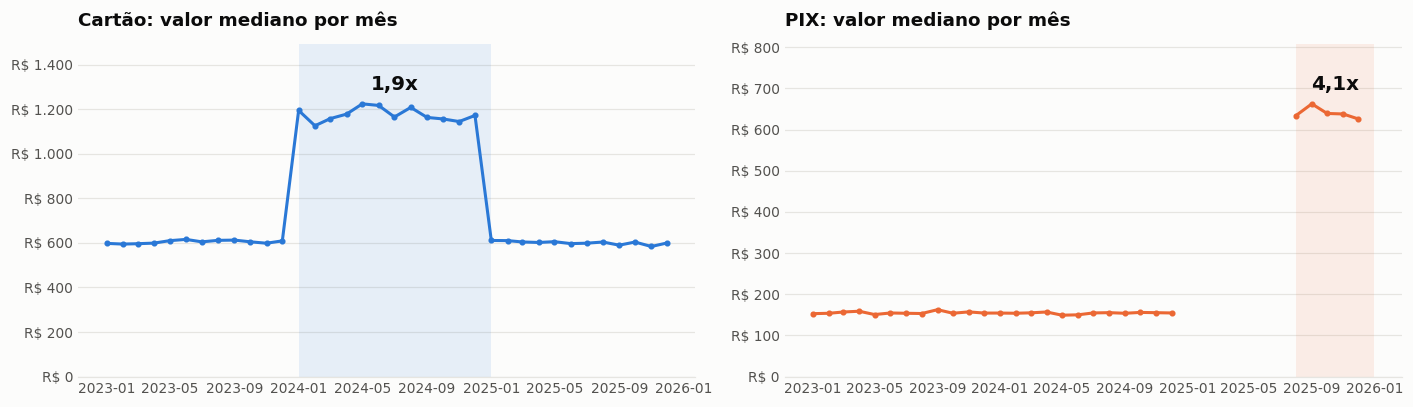

mediana do valor da compra, por ano:
Data
2023     604.83
2024    1172.75
2025     602.14


In [10]:
meses = pd.period_range('2023-01', '2025-12', freq='M')

med_cartao = aut[aut.Valor_Compra > 0].groupby('mes').Valor_Compra.median().reindex(meses)
pix_ok = pix[(pix.Aprovado == 1) & (pix.Valor > 0) & pix.Data.notna()]
med_pix = pix_ok.groupby(pix_ok.Data.dt.to_period('M')).Valor.median().reindex(meses)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, s, cor, tit, ini, fim in [
        (axes[0], med_cartao, AZUL,    'Cartão: valor mediano por mês', '2024-01', '2024-12'),
        (axes[1], med_pix,    LARANJA, 'PIX: valor mediano por mês',    '2025-08', '2025-12')]:
    x = s.index.to_timestamp()
    ax.plot(x, s.values, color=cor, marker='o', markersize=3)
    t0, t1 = pd.Timestamp(ini), pd.Timestamp(fim) + pd.offsets.MonthEnd(0)
    ax.axvspan(t0, t1, color=cor, alpha=0.10, lw=0)
    dentro = s[(x >= t0) & (x <= t1)].median()
    fora   = s[(x <  t0) | (x >  t1)].median()
    ax.text(t0 + (t1-t0)/2, np.nanmax(s.values)*1.05, f'{dentro/fora:.1f}x'.replace('.', ','),
            ha='center', fontsize=13, fontweight='bold', color=TINTA)
    ax.set_ylim(0, np.nanmax(s.values)*1.22); ax.yaxis.set_major_formatter(rs)
    ax.set_title(tit)
plt.tight_layout(); plt.show()

print('mediana do valor da compra, por ano:')
print(aut[aut.Valor_Compra > 0].groupby(aut.Data.dt.year).Valor_Compra.median().round(2).to_string())

Em 2023 e 2025 a compra mediana é ~R$ 600. Em 2024 vira R$ 1.170 e depois volta. A distribuição
inteira se desloca de um mês para o outro — é como se alguém tivesse trocado a régua no meio da
medição. O mesmo acontece com o PIX a partir de ago/2025, com fator ~4x.

Na prática: somar reais entre períodos diferentes daria um crescimento de +156% em 2024 que não
existiu. Por isso trabalho com contagem.

### 3. Sete meses de PIX não existem

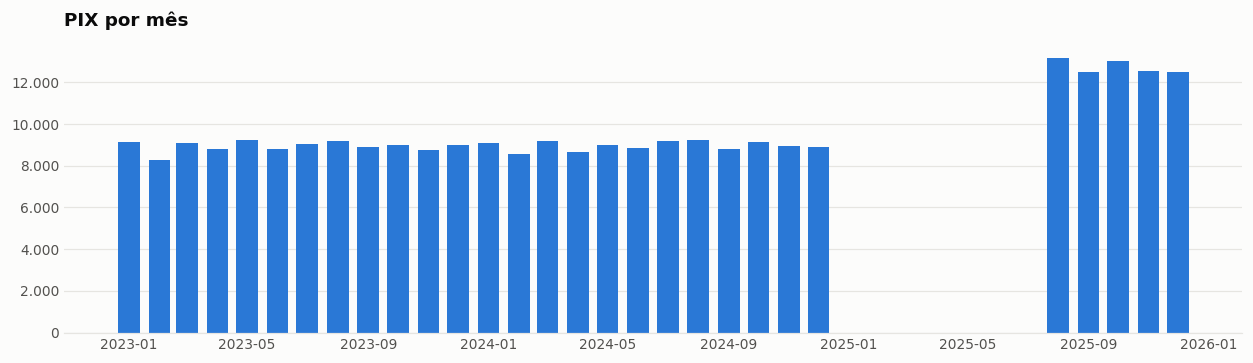

meses sem nenhum registro: 2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2025-06, 2025-07

média mensal antes de 2025: 8.951
média mensal de ago/25 em diante: 12.741


In [11]:
por_mes = pix.dropna(subset=['Data']).groupby(pix.dropna(subset=['Data']).Data.dt.to_period('M')).size()
por_mes = por_mes.reindex(meses, fill_value=0)
vazios = por_mes[por_mes == 0]

fig, ax = plt.subplots(figsize=(11.5, 3.4))
x = por_mes.index.to_timestamp()
ax.bar(x, por_mes.values, width=22, color=[ROSA if v == 0 else AZUL for v in por_mes.values])
ax.yaxis.set_major_formatter(mil)
ax.set_title('PIX por mês')
plt.tight_layout(); plt.show()

print('meses sem nenhum registro:', ', '.join(str(p) for p in vazios.index))
print(f'\nmédia mensal antes de 2025: {por_mes[por_mes.index < "2025-01"].mean():,.0f}'.replace(',', '.'))
print(f'média mensal de ago/25 em diante: {por_mes[por_mes.index >= "2025-08"].mean():,.0f}'.replace(',', '.'))

Some tudo entre janeiro e julho de 2025, e quando volta o volume está num patamar 40% maior. Não dá
para separar "os clientes pararam de usar PIX" de "os dados não foram extraídos", então qualquer
conclusão sobre PIX em 2025 fica frágil.

## Resumo

Do lado do negócio:

- a carteira de clientes caiu 3%, mas o uso por cliente caiu 48%
- a aquisição caiu de ~178 para 27 contas por trimestre
- a emissão de cartões parou em maio de 2025
- só metade dos clientes investe

Do lado dos dados: duas quebras de escala nos valores, sete meses faltando no PIX e duas colunas
inutilizáveis. Por isso o diagnóstico vai ser construído em cima de contagem e participação, não de
reais.

A hipótese que sai daqui é que o banco não está perdendo clientes, está perdendo espaço na carteira
deles. Isso e mais oito hipóteses são testadas no notebook 3. Antes disso, o notebook 2 trata os
problemas encontrados aqui.